In [86]:
import sympy as sym
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as signal

In [87]:
def integrate(f, xt, t, dt):
    """
    This function takes in an initial condition x(t) and a timestep dt,
    as well as a dynamical system f(x) that outputs a vector of the
    same dimension as x(t). It outputs a vector x(t+dt) at the future
    time step.

    Parameters
    ============
    dyn: Python function
        derivate of the system at a given step x(t),
        it can considered as \dot{x}(t) = func(x(t))
    xt: NumPy array
        current step x(t)
    dt:
        step size for integration

    Return
    ============
    new_xt:
        value of x(t+dt) integrated from x(t)
    """
    k1 = dt * f(xt, t)
    k2 = dt * f(xt+k1/2., t + dt/2.)
    k3 = dt * f(xt+k2/2., t + dt/2.)
    k4 = dt * f(xt+k3, t + dt)
    new_xt = xt + (1/6.) * (k1+2.0*k2+2.0*k3+k4)
    return new_xt

def simulate(f, x0, tspan, dt, integrate):
    """
    This function takes in an initial condition x0, a timestep dt,
    a time span tspan consisting of a list [min_time, max_time],
    as well as a dynamical system f(x) that outputs a vector of the
    same dimension as x0. It outputs a full trajectory simulated
    over the time span of dimensions (xvec_size, time_vec_size).

    Parameters
    ============
    f: Python function
        derivate of the system at a given step x(t),
        it can considered as \dot{x}(t) = func(x(t))
    x0: NumPy array
        initial conditions
    tspan: Python list
        tspan = [min_time, max_time], it defines the start and end
        time of simulation
    dt:
        time step for numerical integration
    integrate: Python function
        numerical integration method used in this simulation

    Return
    ============
    x_traj:
        simulated trajectory of x(t) from t=0 to tf
    """
    N = int((max(tspan)-min(tspan))/dt)
    x = np.copy(x0)
    tvec = np.linspace(min(tspan),max(tspan),N)
    xtraj = np.zeros((len(x0),N))
    for i in range(N):
        t = tvec[i]
        xtraj[:,i]=integrate(f,x,t,dt)
        x = np.copy(xtraj[:,i])
    return xtraj, tvec

<>:2: SyntaxWarning: invalid escape sequence '\d'
<>:31: SyntaxWarning: invalid escape sequence '\d'
<>:2: SyntaxWarning: invalid escape sequence '\d'
<>:31: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_1676731/646551329.py:2: SyntaxWarning: invalid escape sequence '\d'
  """
/tmp/ipykernel_1676731/646551329.py:31: SyntaxWarning: invalid escape sequence '\d'
  """


In [88]:
t, G ,J_cap, N, tau = sym.symbols(r't, G, J_{cap}, N, \tau_m')
J_jaw = N * J_cap

# J_1 = 1/2 * m1 * r1**2
# J_2 = 1/2 * m2 * r2**2

th1 = sym.Function(r'\theta_1')(t)
th2 = sym.Function(r'\theta_2')(t)
q = sym.Matrix([th1, th2])
q_dot = q.diff(t)
q_ddot = q_dot.diff(t)

# Relationship between the two pulleys
q_dot[1] = q_dot[0] / G

KE = 1/2 * J_cap * q_dot[0]**2 + 1/2 * J_jaw* q_dot[1]**2

# display(KE)

# Ignoring potential energy for now
L = KE

dLdq = L.diff(q[0])
dLdq_dot = L.diff(q_dot[0])
d_dLdq_dot_dt = dLdq_dot.diff(t)

lhs = d_dLdq_dot_dt - dLdq
rhs = tau

print("The equation of motion for the first pulley:")
eqn = sym.Eq(lhs, rhs)
display(sym.simplify(eqn))
soln = sym.solve(eqn, q_ddot[0])
print("The solution for the acceleration of the capstan:")
display(soln[0])

print("The solution for the acceleration of the jaw:")
soln2 = soln[0] / G
display(soln2)

J_eq = sym.simplify(tau / soln[0])
print("Mqddot = tau form, with the reflected inerta at the motor:")
display(sym.Eq(sym.Symbol('J_eq'), J_eq))


The equation of motion for the first pulley:


Eq(\tau_m, 1.0*J_{cap}*(G**2 + N)*Derivative(\theta_1(t), (t, 2))/G**2)

The solution for the acceleration of the capstan:


G**2*\tau_m/(J_{cap}*(G**2 + N))

The solution for the acceleration of the jaw:


G*\tau_m/(J_{cap}*(G**2 + N))

Mqddot = tau form, with the reflected inerta at the motor:


Eq(J_eq, J_{cap} + J_{cap}*N/G**2)

In [89]:
thetaddot1_num = sym.lambdify((J_cap, N, G, tau), soln[0])

Shape of traj:  (2, 100000)


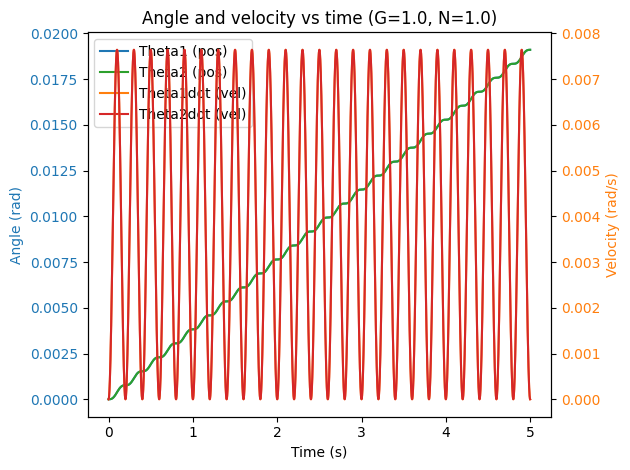

In [90]:
def make_dyn(J_cap_val, N_val, G_val, tau_amp, freq):
    def dyn(s, t):
        """
        System dynamics function (extended)

        Parameters
        ============
        s: NumPy array
            s = [theta1, theta1dot] is the extended system
            state vector, includng the position and
            the velocity of the particle

        Return
        ============
        sdot: NumPy array
            time derivative of input state vector,
            sdot = [theta1dot, theta1ddot]
        """
        # Call the lambdified functions with the current state s
        tau_val = tau_amp * np.sin(2 * np.pi * freq * t)
        thetaddot1_val = thetaddot1_num(J_cap_val, N_val, G_val, tau_val)

        # Return the derivatives
        return np.array([s[1], thetaddot1_val])
    return dyn

# No gear ratio and matched inertias
J_cap_val, N_val, G_val = 1.0, 1.0, 1.0
tau_amp = 0.24 # Torque amplitude (Nm) for motor
freq = 5.0

timestep = 0.00005
# define initial state
# Theta1 = 0, Theta_dot1 = 0
s0 = np.array([0,0])

dyn = make_dyn(J_cap_val, N_val, G_val, tau_amp, freq)
traj1, time = simulate(dyn, s0, [0, 5], timestep, integrate)
accel1 = np.gradient(traj1[1, :], timestep)
print('\033[1mShape of traj: \033[0m', traj1.shape)

traj2 = np.array([traj1[0, :] / G_val, traj1[1, :] / G_val])
accel2 = np.gradient(traj2[1, :], timestep)


fig, ax1 = plt.subplots()

ax1.plot(time, traj1[0, :], color='tab:blue', label='Theta1 (pos)')
ax1.plot(time, traj2[0, :], color='tab:green', label='Theta2 (pos)')
# ax1.plot(time, accel1, color='tab:cyan', label='Theta1ddot (accel)')
# ax1.plot(time, accel2, color='tab:purple', label='Theta2ddot (accel)')
ax1.set_xlabel('Time (s)')
ax1.set_ylabel('Angle (rad)', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')

ax2 = ax1.twinx()
ax2.plot(time, traj1[1, :], color='tab:orange', label='Theta1dot (vel)')
ax2.plot(time, traj2[1, :], color='tab:red', label='Theta2dot (vel)')
ax2.set_ylabel('Velocity (rad/s)', color='tab:orange')
ax2.tick_params(axis='y', labelcolor='tab:orange')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.title(f'Angle and velocity vs time (G={G_val}, N={N_val})')
fig.tight_layout()
plt.show()

In [91]:
# Isolate the last 2 seconds (assuming freq = 5.0 Hz, 2s = 10 full cycles)
steady_state_time = 2.0 
tail_idx = time > (time[-1] - steady_state_time)

time_tail = time[tail_idx]
pos_tail = traj1[0, tail_idx]
vel_tail = traj1[1, tail_idx]
accel_tail = accel1[tail_idx]

# Generate the ideal input torque for this exact time tail
input_torque = tau_amp * np.sin(2 * np.pi * freq * time_tail)

def extract_bode_data(time_array, input_wave, output_wave, frequency, timestep):
    """Detrends output, calculates amplitude, and finds phase shift in degrees."""
    # Remove DC offset / ramp drift
    out_detrended = signal.detrend(output_wave)
    
    # Amplitude
    amplitude = (np.max(out_detrended) - np.min(out_detrended)) / 2.0
    
    # Phase Shift (Cross-Correlation)
    correlation = signal.correlate(out_detrended, input_wave, mode='full')
    lags = signal.correlation_lags(len(out_detrended), len(input_wave), mode='full')
    
    # Find the lag index of maximum correlation
    lag_idx = lags[np.argmax(correlation)]
    
    # Convert lag index to time delay, then to degrees
    time_delay = lag_idx * timestep
    phase_deg = (time_delay * frequency * 360) % 360
    
    # Keep phase bounded between 180 and -180
    if phase_deg > 180:
        phase_deg -= 360
        
    return amplitude, phase_deg

# Extract Position Data
pos_amp, pos_phase = extract_bode_data(time_tail, input_torque, pos_tail, freq, timestep)
print(f"Position     -> Amplitude: {pos_amp:.4f} rad,   Phase: {pos_phase:.1f} deg")

# Extract Velocity Data
vel_amp, vel_phase = extract_bode_data(time_tail, input_torque, vel_tail, freq, timestep)
print(f"Velocity     -> Amplitude: {vel_amp:.4f} rad/s, Phase: {vel_phase:.1f} deg")

# Extract Acceleration Data
accel_amp, accel_phase = extract_bode_data(time_tail, input_torque, accel_tail, freq, timestep)
print(f"Acceleration -> Amplitude: {accel_amp:.4f} rad/s^2, Phase: {accel_phase:.1f} deg")

Position     -> Amplitude: 0.0001 rad,   Phase: 179.9 deg
Velocity     -> Amplitude: 0.0038 rad/s, Phase: 89.0 deg
Acceleration -> Amplitude: 0.1297 rad/s^2, Phase: -0.1 deg


In [92]:
def run_frequency_sweep(J1_val, n_val, G_val, tau_amp, freq_sweep, timestep=0.0005, sim_time=2.0, tail_frac=0.25):
    """
    Sweeps the input torque frequency for one (J1, n, G) parameter set and
    extracts the Bode magnitude/phase of theta1 (motor-side) position,
    velocity, and acceleration at each frequency.

    tail_frac sets the steady-state window as a fraction of sim_time, but is
    floored at 2 full cycles of the current frequency -- the original fixed
    0.5s tail window was less than one cycle at the low end of a 1-100 Hz
    sweep, which made the correlation-based phase estimate unreliable there.
    """
    results = {k: [] for k in ['amps_pos', 'phases_pos', 'amps_vel', 'phases_vel', 'amps_accel', 'phases_accel']}
    s0 = np.array([0.0, 0.0])
    for f in freq_sweep:
        dyn_f = make_dyn(J1_val, n_val, G_val, tau_amp, f)
        traj, t_vec = simulate(dyn_f, s0, [0, sim_time], timestep, integrate)
        accel = np.gradient(traj[1, :], timestep)

        tail_time = max(tail_frac * sim_time, 2.0 / f)
        tail_idx = t_vec > (t_vec[-1] - tail_time)
        input_wave = tau_amp * np.sin(2 * np.pi * f * t_vec[tail_idx])

        a_p, p_p = extract_bode_data(t_vec[tail_idx], input_wave, traj[0, tail_idx], f, timestep)
        a_v, p_v = extract_bode_data(t_vec[tail_idx], input_wave, traj[1, tail_idx], f, timestep)
        a_a, p_a = extract_bode_data(t_vec[tail_idx], input_wave, accel[tail_idx], f, timestep)

        results['amps_pos'].append(a_p); results['phases_pos'].append(p_p)
        results['amps_vel'].append(a_v); results['phases_vel'].append(p_v)
        results['amps_accel'].append(a_a); results['phases_accel'].append(p_a)
    return {k: np.array(v) for k, v in results.items()}

freq_sweep = np.logspace(0, 2, 40)  # 1-100 Hz

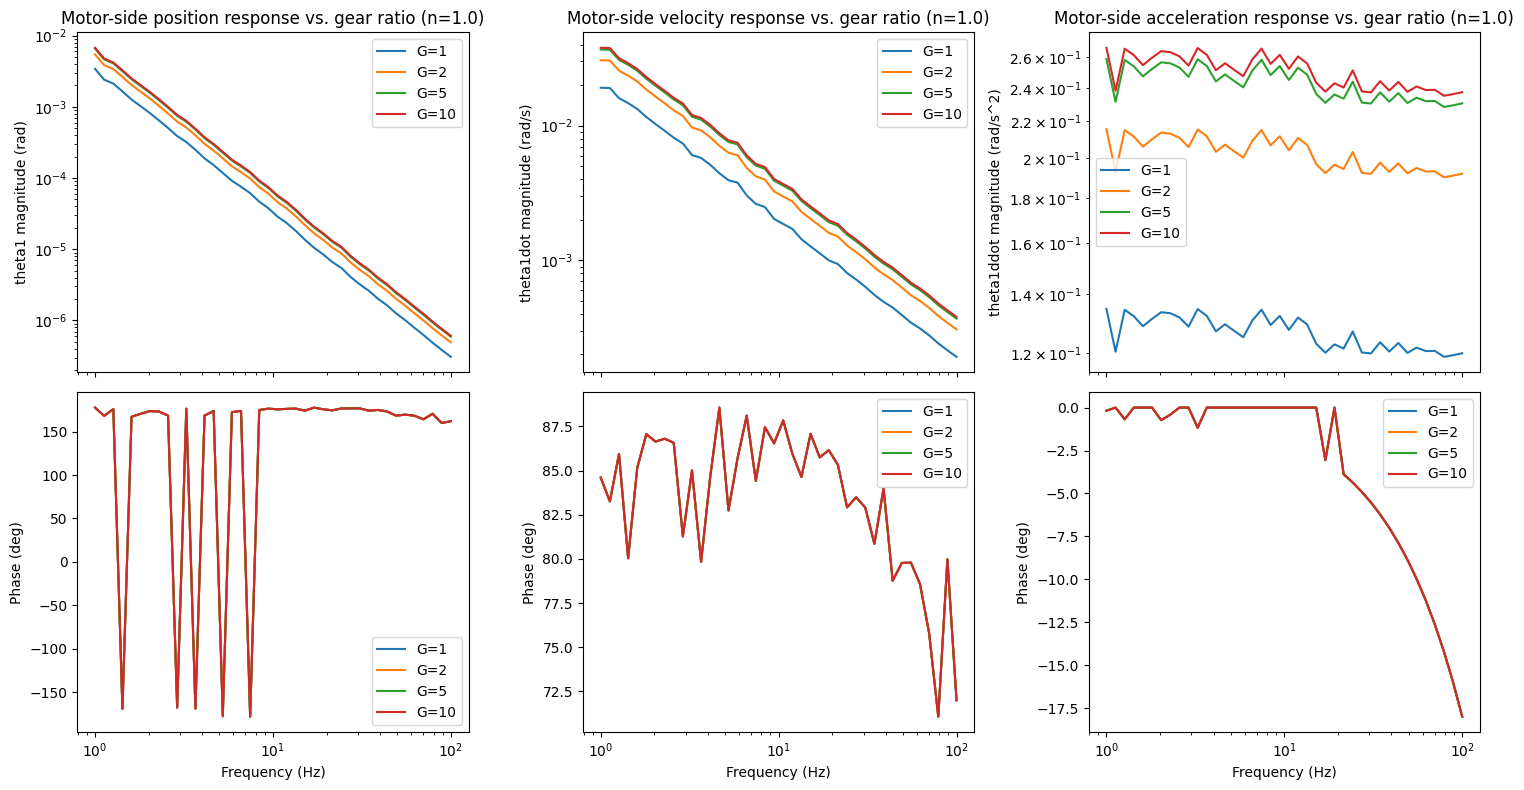

Equivalent inertia at the motor, J_eq = J1*(1 + n/G^2), with J1=1, n=1:
     G   J_eq (theory)   accel mag (theory)    accel mag (sim, mean)
     1          2.0000               0.1200                   0.1265
     2          1.2500               0.1920                   0.2024
     5          1.0400               0.2308                   0.2433
    10          1.0100               0.2376                   0.2505


In [93]:
n_fixed = 1.0
G_values = [1, 2, 5, 10]
sweep_by_G = {Gv: run_frequency_sweep(1.0, n_fixed, Gv, tau_amp, freq_sweep) for Gv in G_values}

fig, ax = plt.subplots(2, 3, figsize=(15, 8), sharex=True)
for Gv in G_values:
    ax[0,0].loglog(freq_sweep, sweep_by_G[Gv]['amps_pos'], label=f'G={Gv}')
    ax[0,1].loglog(freq_sweep, sweep_by_G[Gv]['amps_vel'], label=f'G={Gv}')
    ax[0,2].loglog(freq_sweep, sweep_by_G[Gv]['amps_accel'], label=f'G={Gv}')
    ax[1,0].semilogx(freq_sweep, sweep_by_G[Gv]['phases_pos'], label=f'G={Gv}')
    ax[1,1].semilogx(freq_sweep, sweep_by_G[Gv]['phases_vel'], label=f'G={Gv}')
    ax[1,2].semilogx(freq_sweep, sweep_by_G[Gv]['phases_accel'], label=f'G={Gv}')
ax[0,0].set_ylabel('theta1 magnitude (rad)')
ax[0,0].set_title(f'Motor-side position response vs. gear ratio (n={n_fixed})')
ax[0,0].legend()
ax[0,1].set_ylabel('theta1dot magnitude (rad/s)')
ax[0,1].set_title(f'Motor-side velocity response vs. gear ratio (n={n_fixed})')
ax[0,1].legend()
ax[0,2].set_ylabel('theta1ddot magnitude (rad/s^2)')
ax[0,2].set_title(f'Motor-side acceleration response vs. gear ratio (n={n_fixed})')
ax[0,2].legend()   
ax[1,0].set_ylabel('Phase (deg)')
ax[1,0].set_xlabel('Frequency (Hz)')
ax[1,0].legend()
ax[1,1].set_ylabel('Phase (deg)')
ax[1,1].set_xlabel('Frequency (Hz)')
ax[1,1].legend()
ax[1,2].set_ylabel('Phase (deg)')
ax[1,2].set_xlabel('Frequency (Hz)')
ax[1,2].legend()

fig.tight_layout()
plt.show()

print("Equivalent inertia at the motor, J_eq = J1*(1 + n/G^2), with J1=1, n=1:")
print(f"{'G':>6} {'J_eq (theory)':>15} {'accel mag (theory)':>20} {'accel mag (sim, mean)':>24}")
for Gv in G_values:
    Jeq = 1.0 * (1 + n_fixed / Gv**2)
    print(f"{Gv:>6} {Jeq:>15.4f} {tau_amp/Jeq:>20.4f} {np.mean(sweep_by_G[Gv]['amps_accel']):>24.4f}")

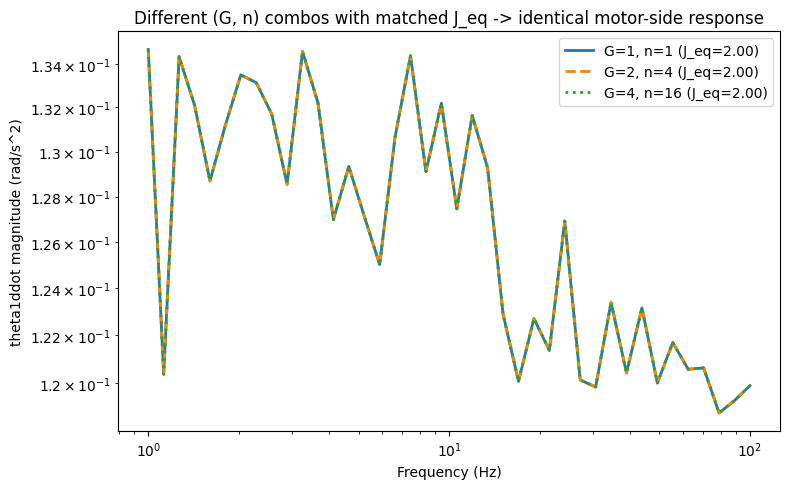

Same J_eq, different physical design -- the motor-referred response is identical:
  G= 1, n= 1  ->  mean accel magnitude = 0.1265 rad/s^2
  G= 2, n= 4  ->  mean accel magnitude = 0.1265 rad/s^2
  G= 4, n=16  ->  mean accel magnitude = 0.1265 rad/s^2

Note: this equivalence is only in the motor-referred (theta1) response.
The physical jaw motion theta2 = theta1/G still differs between these three
designs -- the same dynamic 'feel' at the motor does not mean the same jaw speed.


In [94]:
combos = [(1, 1), (2, 4), (4, 16)]  # each gives J_eq = 2.0 with J1 = 1
sweep_by_combo = {(Gv, nv): run_frequency_sweep(1.0, nv, Gv, tau_amp, freq_sweep) for (Gv, nv) in combos}

fig, ax = plt.subplots(figsize=(8, 5))
styles = ['-', '--', ':']
for (Gv, nv), ls in zip(combos, styles):
    Jeq = 1.0 * (1 + nv / Gv**2)
    ax.loglog(freq_sweep, sweep_by_combo[(Gv, nv)]['amps_accel'],
               linestyle=ls, linewidth=2, label=f'G={Gv}, n={nv} (J_eq={Jeq:.2f})')
ax.set_ylabel('theta1ddot magnitude (rad/s^2)')
ax.set_xlabel('Frequency (Hz)')
ax.set_title('Different (G, n) combos with matched J_eq -> identical motor-side response')
ax.legend()
fig.tight_layout()
plt.show()

print("Same J_eq, different physical design -- the motor-referred response is identical:")
for (Gv, nv) in combos:
    print(f"  G={Gv:>2}, n={nv:>2}  ->  mean accel magnitude = {np.mean(sweep_by_combo[(Gv, nv)]['amps_accel']):.4f} rad/s^2")

print()
print("Note: this equivalence is only in the motor-referred (theta1) response.")
print("The physical jaw motion theta2 = theta1/G still differs between these three")
print("designs -- the same dynamic 'feel' at the motor does not mean the same jaw speed.")

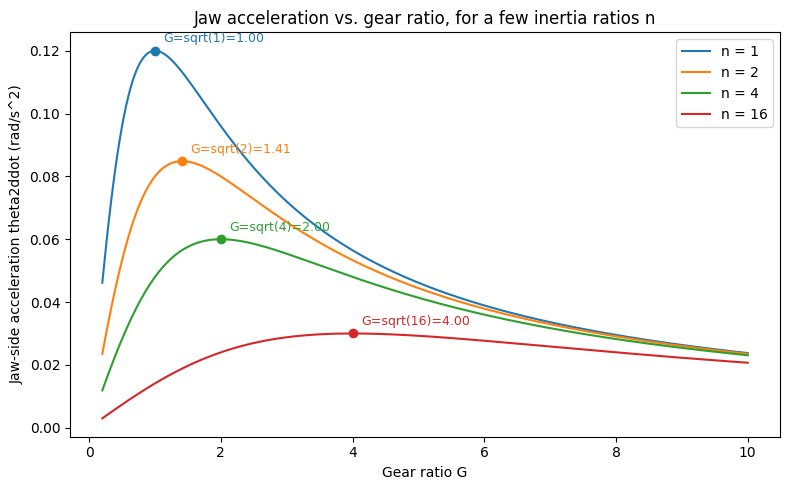

Inertia-matched gear ratio G = sqrt(n)  (equivalently n = G^2):
  n =   1  ->  G_opt = 1.000   (reflected load inertia at G_opt = J2/G_opt^2 = 1.000 = J1, as expected)
  n =   4  ->  G_opt = 2.000   (reflected load inertia at G_opt = J2/G_opt^2 = 1.000 = J1, as expected)
  n =  16  ->  G_opt = 4.000   (reflected load inertia at G_opt = J2/G_opt^2 = 1.000 = J1, as expected)


In [95]:
G_range = np.linspace(0.2, 10, 300)

fig, ax = plt.subplots(figsize=(8, 5))
for n_val in [1, 2, 4, 16]:
    theta1ddot = thetaddot1_num(1.0, n_val, G_range, tau_amp)  # J1 = 1
    theta2ddot = theta1ddot / G_range  # jaw-side (load) acceleration

    line, = ax.plot(G_range, theta2ddot, label=f'n = {n_val}')

    G_opt = np.sqrt(n_val)  # textbook: G = sqrt(J_load/J_motor) = sqrt(n)
    theta2ddot_opt = tau_amp / (1.0 * (G_opt + n_val / G_opt))
    ax.plot(G_opt, theta2ddot_opt, 'o', color=line.get_color())
    ax.annotate(f'G=sqrt({n_val})={G_opt:.2f}', (G_opt, theta2ddot_opt),
                textcoords='offset points', xytext=(6, 6), fontsize=9, color=line.get_color())

ax.set_xlabel('Gear ratio G')
ax.set_ylabel('Jaw-side acceleration theta2ddot (rad/s^2)')
ax.set_title('Jaw acceleration vs. gear ratio, for a few inertia ratios n')
ax.legend()
fig.tight_layout()
plt.show()

print("Inertia-matched gear ratio G = sqrt(n)  (equivalently n = G^2):")
for n_val in [1, 4, 16]:
    G_opt = np.sqrt(n_val)
    J2_reflected = 1.0 * n_val / G_opt**2
    print(f"  n = {n_val:>3}  ->  G_opt = {G_opt:.3f}   "
          f"(reflected load inertia at G_opt = J2/G_opt^2 = {J2_reflected:.3f} = J1, as expected)")